# Ερώτημα 3 - Clustering (CIC-IDS-2017)

**Στόχοι αυτού του notebook**

1. Φόρτωση του καθαρού, feature-selected dataset που παρήγαγε το Q1.
2. Προεπεξεργασία χωρίς τη στήλη `Label` (unsupervised setting): `StandardScaler` + `PCA` με αριθμό components που καλύπτει ≥85% της variance.
3. Εκπαίδευση τριών αλγορίθμων clustering με τις παραμέτρους που ορίζει η εκφώνηση:
   - **K-Means** (Elbow + Silhouette για επιλογή του k, plus reference run στο k = 15 = #true labels)
   - **Hierarchical** (Agglomerative) με linkage ∈ {ward, complete, average}
   - **DBSCAN** (k-distance graph για ε, sweep πάνω σε ε × min_samples)
4. Αξιολόγηση με **Silhouette score** και **Davies-Bouldin Index** (όπως ζητά η εκφώνηση).
5. Visualization σε 2-D PCA scatter: cluster-colored vs Label-colored side-by-side.
6. Cluster-to-Label heatmap για να δούμε αν οι ανακαλυφθείσες clusters αντιστοιχούν σε γνωστές attack categories.
7. Συγκριτικός πίνακας και απάντηση στις ερωτήσεις της εκφώνησης.

> **Σχέση με Q2.** Στο Q2 *ξέρουμε* τα labels και εκπαιδεύουμε supervised classifier. Στο Q3 **αποκρύπτουμε** τα labels κατά το training του clustering και τα ξαναφέρνουμε *μόνο* για post-hoc αξιολόγηση. Αυτό μας λέει αν η δομή των δεδομένων εξηγεί από μόνη της τις attack categories - χωρίς supervisory signal.

## 0. Imports και environment setup

In [1]:
import sys
import time
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings('ignore', message='.*Number of distinct clusters.*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage as scipy_linkage, fcluster

from utils import (
    RANDOM_STATE,
    load_clean_cached,
    evaluate_clustering,
    plot_elbow_silhouette,
    plot_k_distance,
    plot_pca_scatter_comparison,
    plot_cluster_label_heatmap,
    plot_dendrogram,
    save_figure,
    save_results,
)

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

import sklearn; print('scikit-learn', sklearn.__version__)
print('Random seed', RANDOM_STATE)


scikit-learn 1.8.0
Random seed 42


## ⚙️ Configuration - επιλογή μεγέθους εκπαίδευσης

Ίδιο pattern με το Q2: η μεταβλητή `SUBSAMPLE_CAP` ελέγχει το per-class cap για όλο το Q3, **εκτός** από το Hierarchical Clustering που έχει δικό του (πολύ μικρότερο) cap λόγω του O(n²) memory cost της full distance matrix.

| Mode    | `SUBSAMPLE_CAP` | Συνολικά rows | Αναμενόμενος χρόνος* | Συνιστάται |
|---|---|---|---|---|
| **fast**   | `25_000`  | ~134K   | ~10-20 min  | iteration, debugging |
| **medium** | `100_000` | ~500K   | ~30-90 min  | ισχυρότερα μετρικά |
| **full**   | `None`    | ~2.5M   | ~3-6 hours  | reference run |

*Σύγχρονο laptop με 8 cores. Bottleneck σε όλα τα modes είναι το DBSCAN sweep (15 combos).

**Hierarchical cap.** Η AgglomerativeClustering απαιτεί ολόκληρο τον (n × n) πίνακα αποστάσεων: για 134K rows αυτό είναι ~72 GB μνήμη - απαγορευτικό. Παίρνουμε ξεχωριστό **stratified subsample 3.000 rows** μόνο για το hierarchical (~70 MB distance matrix). Είναι αρκετό για να αποκαλύψει τη δομή και να παράγει διαβάσιμο dendrogram.

**Σύσταση**: αρχικά τρέξτε σε `fast` για να επαληθεύσετε ότι όλα παράγονται· μετά σε `medium` αν θέλετε πιο σταθερά metrics.

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ΑΛΛΑΞΕ ΕΔΩ ΤΟ MODE                                              ║
# ║  fast   → SUBSAMPLE_CAP = 25_000   (~134K rows, ~10-20 min)      ║
# ║  medium → SUBSAMPLE_CAP = 100_000  (~500K rows, ~30-90 min)      ║
# ║  full   → SUBSAMPLE_CAP = None     (~2.5M rows, ~3-6 hours)      ║
# ╚══════════════════════════════════════════════════════════════════╝
SUBSAMPLE_CAP: int | None = 25_000

# Hierarchical-only cap (O(n²) memory). 3000 rows → ~70 MB distance matrix.
HIER_SAMPLE_SIZE: int = 3_000

# Silhouette is O(n²); we sample for speed. ±0.01 accuracy at n=10K.
SILHOUETTE_SAMPLE_SIZE: int = 10_000

# PCA target — keep components covering at least this much variance.
PCA_VARIANCE_TARGET: float = 0.85

# K-Means / Hierarchical: try k from 2..K_MAX inclusive.
K_MAX: int = 15

# DBSCAN sweep grid (όπως ορίζει η εκφώνηση).
DBSCAN_EPS_GRID = [0.3, 0.5, 0.8, 1.0, 1.5]
DBSCAN_MIN_SAMPLES_GRID = [5, 10, 20]

MODE_NAME = ('FULL DATASET' if SUBSAMPLE_CAP is None
             else f'SUBSAMPLED with cap={SUBSAMPLE_CAP:,}')
print(f'Mode                  : {MODE_NAME}')
print(f'Hierarchical sample   : {HIER_SAMPLE_SIZE:,} rows')
print(f'Silhouette sample     : {SILHOUETTE_SAMPLE_SIZE:,} rows')
print(f'PCA variance target   : {PCA_VARIANCE_TARGET:.0%}')
print(f'K-Means / Hier k-range: 2..{K_MAX}')
print(f'DBSCAN ε grid         : {DBSCAN_EPS_GRID}')
print(f'DBSCAN min_samples    : {DBSCAN_MIN_SAMPLES_GRID}')


Mode                  : SUBSAMPLED with cap=25,000
Hierarchical sample   : 3,000 rows
Silhouette sample     : 10,000 rows
PCA variance target   : 85%
K-Means / Hier k-range: 2..15
DBSCAN ε grid         : [0.3, 0.5, 0.8, 1.0, 1.5]
DBSCAN min_samples    : [5, 10, 20]


## 3.1 Preprocessing για clustering

Σε contrast με το Q2:
1. **Αποκρύπτουμε το `Label`** κατά το fit όλων των clustering αλγορίθμων. Το ξαναφέρνουμε μόνο για post-hoc αξιολόγηση (cluster-to-label heatmap).
2. **StandardScaler είναι κρίσιμο** εδώ - ακόμα πιο σημαντικό από Q2. Τα clustering αλγόριθμα είναι distance-based (ευκλείδεια απόσταση μεταξύ points). Αν ένα feature είναι σε scale 10⁶ (Bytes/s) και ένα άλλο σε scale 1 (PSH Flag Count), η ευκλείδεια απόσταση θα κυριαρχείται 100% από το πρώτο. Όλα τα features πρέπει να συνεισφέρουν εξίσου.
3. **PCA** για dimensionality reduction. Δύο λόγοι:
   - Distance-based αλγόριθμοι υποφέρουν από **curse of dimensionality**: σε υψηλές διαστάσεις (47 features), όλες οι αποστάσεις τείνουν να γίνονται παρόμοιες, και η έννοια του «κοντινός γείτονας» χάνει νόημα.
   - Ταχύτητα: K-Means/DBSCAN/Hierarchical είναι O(n × d) ή χειρότερα ως προς τη διάσταση d. Από 47 → 10-15 components είναι 3-5× speedup.
   - Visualization: τα 2 πρώτα components μας δίνουν 2-D scatter.

In [3]:
df = load_clean_cached()
print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')

y_raw = df['Label']
X_raw = df.drop(columns=['Label'])

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print(f'Features: {X_raw.shape[1]}')
print(f'Classes : {len(le.classes_)}')


Shape  : 2,572,640 rows × 48 columns


Features: 47
Classes : 15


### Stratified subsampling (ίδιο pattern με Q2)

Per-class cap ώστε οι rare classes (Heartbleed=11, SQL Injection=21, Infiltration=36, ...) να διατηρούνται πλήρως. Αν `SUBSAMPLE_CAP=None`, χρησιμοποιούμε όλο το dataset.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)

if SUBSAMPLE_CAP is None:
    X = X_raw.reset_index(drop=True)
    y = y_enc.copy()
else:
    keep_idx = []
    for cls in np.unique(y_enc):
        cls_idx = np.where(y_enc == cls)[0]
        if len(cls_idx) > SUBSAMPLE_CAP:
            cls_idx = rng.choice(cls_idx, size=SUBSAMPLE_CAP, replace=False)
        keep_idx.append(cls_idx)
    keep_idx = np.sort(np.concatenate(keep_idx))
    X = X_raw.iloc[keep_idx].reset_index(drop=True)
    y = y_enc[keep_idx]

print(f'Mode    : {MODE_NAME}')
print(f'Active  : {len(y):,} rows  ({len(y)/len(y_enc)*100:.2f}% του original)')


Mode    : SUBSAMPLED with cap=25,000
Active  : 134,187 rows  (5.22% του original)


### StandardScaler + PCA

Επειδή ζούμε στο unsupervised world (δεν υπάρχει train/test split για το clustering), ο scaler και το PCA γίνονται `fit` σε *όλο* το dataset μας. Το data-leakage concern του Q2 δεν εφαρμόζεται εδώ γιατί δεν υπάρχει «held-out test» - απλά παρακολουθούμε quality του clustering πάνω στα ίδια rows.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled shape: {X_scaled.shape}')

# Πρώτα τρέχουμε full PCA για να δούμε το variance curve.
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
n_components = int(np.argmax(cum_var >= PCA_VARIANCE_TARGET) + 1)
print(f'Components needed for ≥{PCA_VARIANCE_TARGET:.0%} variance: {n_components}')
print(f'Cumulative variance at {n_components} comps: {cum_var[n_components-1]:.4f}')


Scaled shape: (134187, 47)
Components needed for ≥85% variance: 17
Cumulative variance at 17 comps: 0.8628


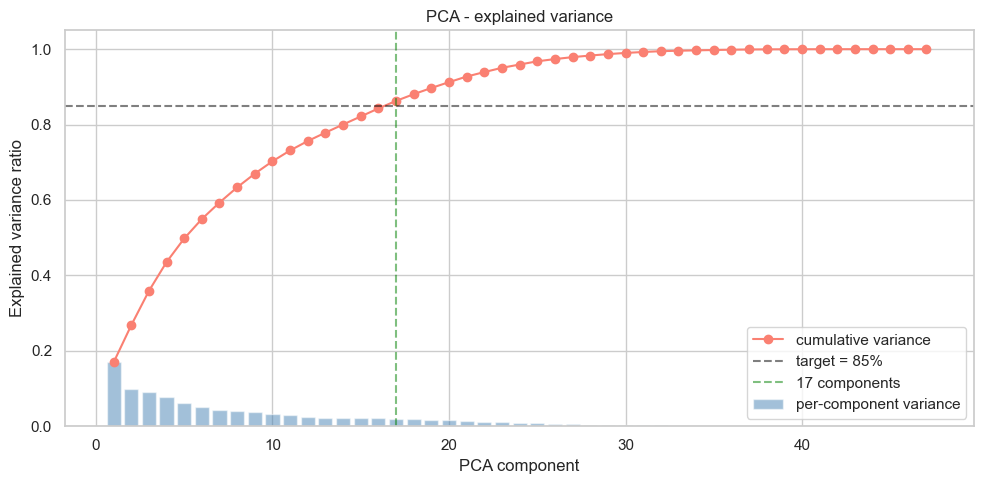

In [6]:
# Plot explained variance curve.
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(var_ratio)+1), var_ratio, alpha=0.5,
       color='steelblue', label='per-component variance')
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='salmon',
        label='cumulative variance')
ax.axhline(PCA_VARIANCE_TARGET, color='black', linestyle='--', alpha=0.5,
           label=f'target = {PCA_VARIANCE_TARGET:.0%}')
ax.axvline(n_components, color='green', linestyle='--', alpha=0.5,
           label=f'{n_components} components')
ax.set_xlabel('PCA component')
ax.set_ylabel('Explained variance ratio')
ax.set_title('PCA - explained variance')
ax.legend()
plt.tight_layout()
save_figure(fig, 'q3_pca_variance.png')
plt.show()
plt.close(fig)


In [7]:
# Refit PCA με τον επιλεγμένο αριθμό components.
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA-reduced shape: {X_pca.shape}')

# Επίσης κρατάμε ένα 2-D PCA για visualizations (ίδιο rotation, μόνο τα 2 πρώτα).
X_pca_2d = X_pca[:, :2]

# Save PCA explained variance ledger.
save_results(pd.DataFrame({
    'component'           : range(1, len(var_ratio)+1),
    'explained_variance'  : var_ratio,
    'cumulative_variance' : cum_var,
}), 'q3_pca_variance.csv')


PCA-reduced shape: (134187, 17)


WindowsPath('D:/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_pca_variance.csv')

**Διδακτικό σημείωμα: γιατί `n_components` = αυτό που είναι.** Κάθε νέο PCA component συλλαμβάνει τη μεγαλύτερη εναπομένουσα variance του scaled feature space. Μετά από κάποιο point η variance που προστίθεται είναι κυρίως noise. Το 85% variance threshold είναι καθιερωμένη heuristic - αρκετή information για clustering, χωρίς το «θόρυβο» των τελευταίων components.

## 3.2 K-Means

**Διαίσθηση.** Επιλέγουμε `k` ως αριθμό clusters. Επανάληψη μέχρι σύγκλιση:
1. **Assignment**: κάθε point ανατίθεται στο πιο κοντινό centroid (ευκλείδεια απόσταση).
2. **Update**: κάθε centroid ξαναϋπολογίζεται ως ο μέσος όρος των points που του ανατέθηκαν.

Συγκλίνει σε local minimum του **inertia** (sum of squared distances των points από το centroid τους).

**Υποθέσεις του K-Means.**
- Clusters είναι περίπου **σφαιρικά** στο feature space.
- Clusters έχουν **παρόμοιο μέγεθος**.
- Γνωρίζουμε εκ των προτέρων το `k`.

**Σε μας.** Οι attack categories δεν είναι σφαιρικές (το BENIGN είναι 80% του dataset, το Heartbleed είναι 0.0004%). Άρα το K-Means θα έχει δυσκολίες - ειδικά να ξεχωρίσει rare attacks. Είναι όμως καλό baseline.

### Επιλογή k - Elbow + Silhouette για k = 2..15

**Elbow method**: σχεδιάζουμε inertia ως συνάρτηση του k. Αρχικά το inertia πέφτει γρήγορα· μετά από κάποιο k το curve «καμπυλώνει» (ο αγκώνας) και το benefit μειώνεται.

**Silhouette score**: για κάθε point, μετράμε πόσο κοντά είναι στο cluster του (`a`) σε σχέση με το πιο κοντινό άλλο cluster (`b`). Επιστρέφει `(b-a)/max(a,b)` ∈ [-1, 1]. Υψηλό = καλό. Σχεδιάζουμε mean silhouette πάνω σε όλα τα points για κάθε k.

In [8]:
ks = list(range(2, K_MAX + 1))
inertias = []
silhouettes = []

t0 = time.time()
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sample = min(SILHOUETTE_SAMPLE_SIZE, len(X_pca))
    sil = silhouette_score(X_pca, km.labels_, sample_size=sample,
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'  k={k:2d}: inertia={km.inertia_:>14,.0f}  silhouette={sil:.4f}')
print(f'\nElapsed: {time.time()-t0:.1f}s')


  k= 2: inertia=     4,567,660  silhouette=0.3740


  k= 3: inertia=     4,326,289  silhouette=0.2027


  k= 4: inertia=     3,945,271  silhouette=0.2148


  k= 5: inertia=     3,613,300  silhouette=0.2614


  k= 6: inertia=     3,500,272  silhouette=0.2793


...

  k=11: inertia=     2,055,658  silhouette=0.3784


  k=12: inertia=     1,774,475  silhouette=0.4020


  k=13: inertia=     1,640,271  silhouette=0.4021


  k=14: inertia=     1,533,860  silhouette=0.4076


  k=15: inertia=     1,444,466  silhouette=0.4237

Elapsed: 31.3s


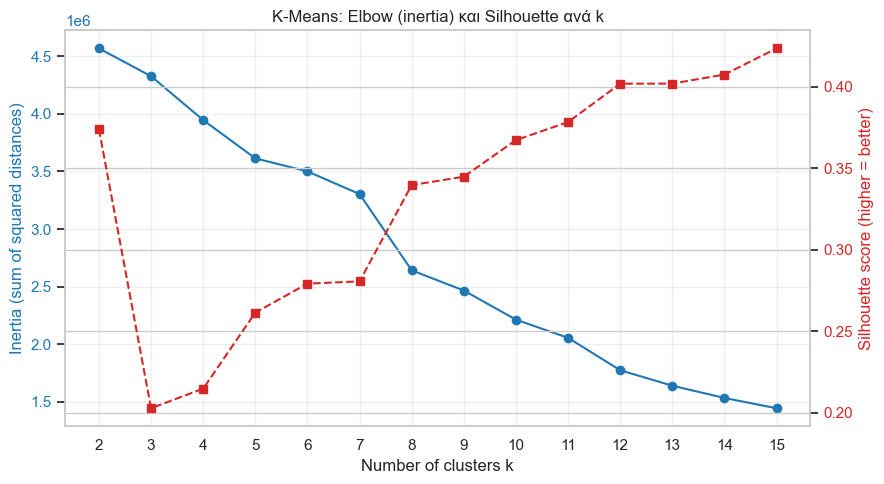

WindowsPath('D:/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_kmeans_k_search.csv')

In [9]:
plot_elbow_silhouette(
    ks, inertias, silhouettes,
    title='K-Means: Elbow (inertia) και Silhouette ανά k',
    fname='q3_kmeans_elbow_silhouette.png',
)

save_results(pd.DataFrame({
    'k': ks, 'inertia': inertias, 'silhouette': silhouettes,
}), 'q3_kmeans_k_search.csv')


In [10]:
# Επιλέγουμε το best k βάσει silhouette (ο elbow είναι ποιοτικός κανόνας).
best_k = ks[int(np.argmax(silhouettes))]
print(f'Best k by silhouette: {best_k}  (silhouette={max(silhouettes):.4f})')
print(f'Reference k         : {K_MAX}  (= number of true Labels)')


Best k by silhouette: 15  (silhouette=0.4237)
Reference k         : 15  (= number of true Labels)


### K-Means με best_k και με reference k = #true labels

Η εκφώνηση ζητά να τρέξουμε K-Means *και* με το best k που βρήκαμε, *και* με `k = 15` (ίσος με τον αριθμό των γνωστών attack categories) για να δούμε αν αναγκάζοντας τον αλγόριθμο να βρει 15 clusters, αυτά αντιστοιχούν στα 15 πραγματικά labels.

In [11]:
km_best = KMeans(n_clusters=best_k, n_init='auto', random_state=RANDOM_STATE).fit(X_pca)
km_ref  = KMeans(n_clusters=K_MAX,  n_init='auto', random_state=RANDOM_STATE).fit(X_pca)

km_best_metrics = evaluate_clustering(X_pca, km_best.labels_,
                                      sample_size=SILHOUETTE_SAMPLE_SIZE,
                                      seed=RANDOM_STATE)
km_ref_metrics  = evaluate_clustering(X_pca, km_ref.labels_,
                                      sample_size=SILHOUETTE_SAMPLE_SIZE,
                                      seed=RANDOM_STATE)
print(f'K-Means best (k={best_k}): {km_best_metrics}')
print(f'K-Means ref  (k={K_MAX}): {km_ref_metrics}')


K-Means best (k=15): {'n_clusters': 15, 'n_noise': 0, 'silhouette': 0.4236891973692973, 'davies_bouldin': 0.8278185242371154}
K-Means ref  (k=15): {'n_clusters': 15, 'n_noise': 0, 'silhouette': 0.4236891973692973, 'davies_bouldin': 0.8278185242371154}


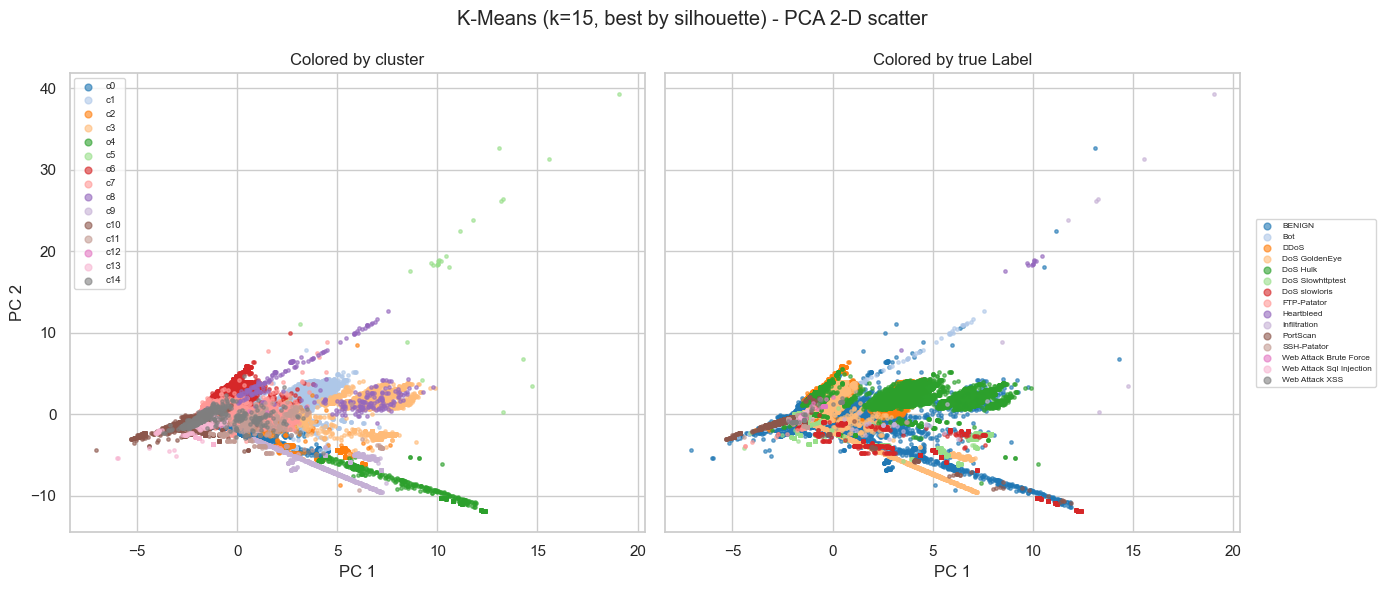

In [12]:
plot_pca_scatter_comparison(
    X_pca_2d, km_best.labels_, y, le.classes_,
    title=f'K-Means (k={best_k}, best by silhouette) - PCA 2-D scatter',
    fname='q3_kmeans_best_scatter.png',
)


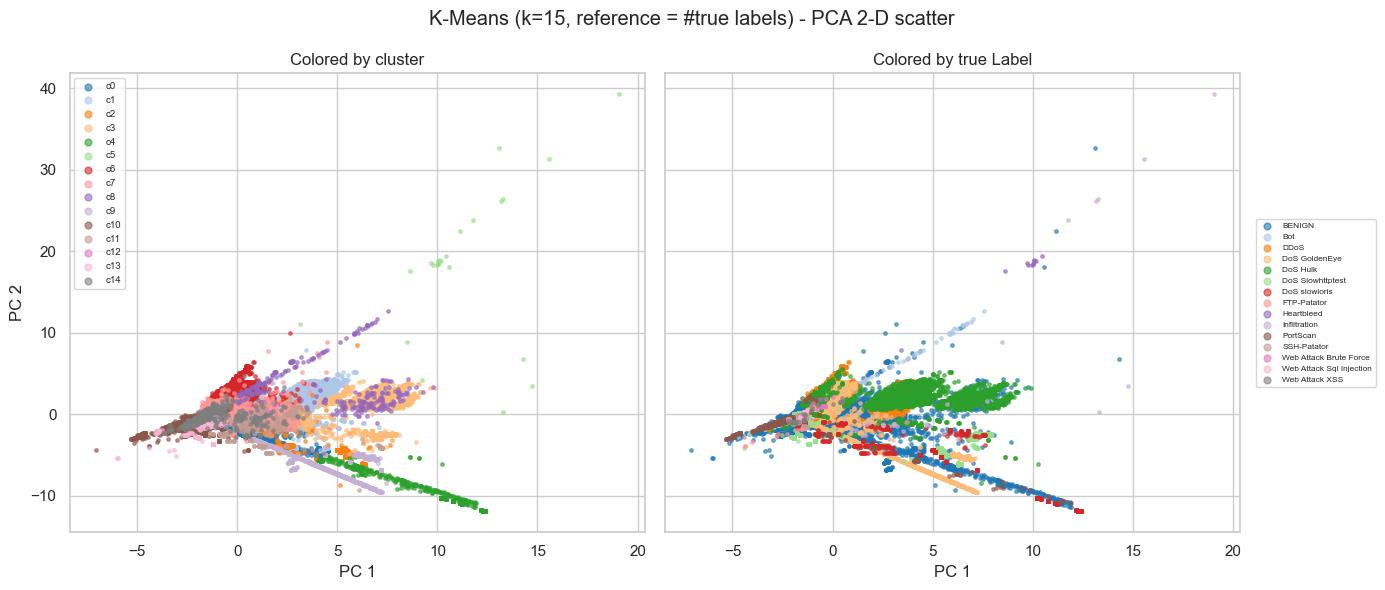

In [13]:
plot_pca_scatter_comparison(
    X_pca_2d, km_ref.labels_, y, le.classes_,
    title=f'K-Means (k={K_MAX}, reference = #true labels) - PCA 2-D scatter',
    fname='q3_kmeans_ref_scatter.png',
)


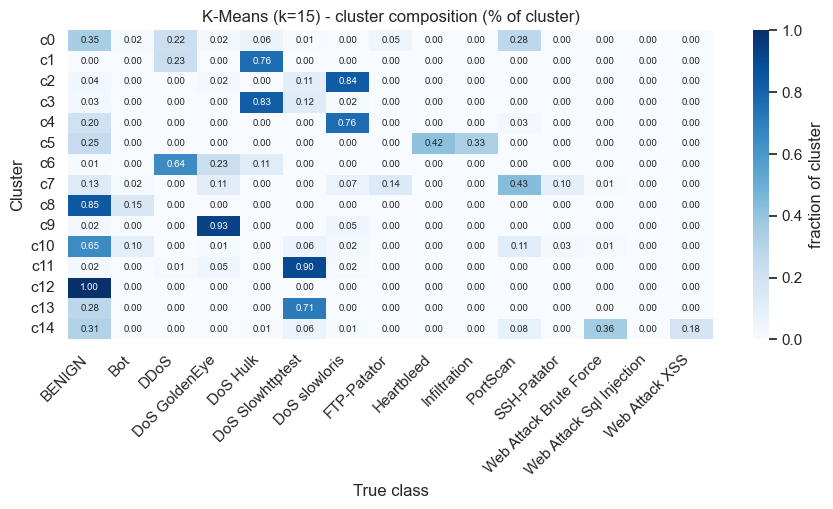

WindowsPath('D:/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_kmeans_best_heatmap.csv')

In [14]:
# Cluster-to-Label heatmap για το best k.
ct_km = plot_cluster_label_heatmap(
    km_best.labels_, y, le.classes_,
    title=f'K-Means (k={best_k}) - cluster composition (% of cluster)',
    fname='q3_kmeans_best_heatmap.png',
    normalize='cluster',
)
save_results(ct_km.reset_index().rename(columns={'index': 'cluster'}),
             'q3_kmeans_best_heatmap.csv')


## 3.3 Hierarchical (Agglomerative) Clustering

**Διαίσθηση.** Bottom-up:
1. Ξεκινάμε με κάθε point ως ένα ξεχωριστό cluster.
2. Σε κάθε βήμα, ενώνουμε τα δύο πιο κοντινά clusters.
3. Συνεχίζουμε μέχρι να μείνει ένα cluster που περιέχει όλα.

Παράγει ένα **dendrogram** - ιεραρχικό δέντρο από merges. Για να πάρουμε k clusters, «κόβουμε» το dendrogram στο σωστό height.

**Linkage methods** - πώς ορίζουμε «απόσταση μεταξύ clusters»:
- **single**: ελάχιστη απόσταση μεταξύ points δύο clusters. Φτιάχνει long chain-like clusters (chaining effect).
- **complete**: μέγιστη απόσταση. Φτιάχνει συμπαγή σφαιρικά clusters.
- **average**: μέσος όρος όλων των ζευγών. Συμβιβασμός.
- **ward** (default): minimum-variance criterion. Ενώνει clusters που η συγχώνευσή τους αυξάνει λιγότερο τη συνολική within-cluster variance. **Συνήθως λειτουργεί καλύτερα** όταν τα clusters είναι περίπου σφαιρικά - όπως στο K-Means.

**Computational cost - γιατί υπο-δειγματίζουμε.** Η AgglomerativeClustering απαιτεί τον πλήρη πίνακα αποστάσεων O(n²): για 134K rows αυτό είναι ~72 GB RAM. Παίρνουμε **stratified subsample 3000 rows** για το hierarchical (~70 MB distance matrix). Αυτό αρκεί για διαβάσιμο dendrogram και αξιόπιστο linkage comparison.

In [15]:
# Stratified subsample για το hierarchical.
rng_h = np.random.default_rng(RANDOM_STATE)
hier_idx_per_class = []
per_class_quota = max(1, HIER_SAMPLE_SIZE // len(le.classes_))
for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    take = min(len(cls_idx), per_class_quota)
    if take > 0:
        chosen = rng_h.choice(cls_idx, size=take, replace=False)
        hier_idx_per_class.append(chosen)
hier_idx = np.sort(np.concatenate(hier_idx_per_class))

X_hier   = X_pca[hier_idx]
X_hier2d = X_pca_2d[hier_idx]
y_hier   = y[hier_idx]
print(f'Hierarchical sample: {len(y_hier):,} rows')
print('Per-class:')
for cls in np.unique(y_hier):
    print(f'  {le.classes_[cls]:<28s} {(y_hier == cls).sum():>5d}')


Hierarchical sample: 2,468 rows
Per-class:
  BENIGN                         200
  Bot                            200
  DDoS                           200
  DoS GoldenEye                  200
  DoS Hulk                       200
  DoS Slowhttptest               200
  DoS slowloris                  200
  FTP-Patator                    200
  Heartbleed                      11
  Infiltration                    36
  PortScan                       200
  SSH-Patator                    200
  Web Attack Brute Force         200
  Web Attack Sql Injection        21
  Web Attack XSS                 200


### Dendrogram (ward linkage, top 30 merges)

Με 3.000 points, το πλήρες dendrogram θα είχε 2.999 merges. Παρουσιάζουμε μόνο τα **top 30 merges** (κάτω-κάτω σε height) - εκεί φαίνεται η μακρο-δομή της ιεραρχίας. Το ύψος κάθε merge δείχνει την απόσταση των δύο clusters που ενώνονται.

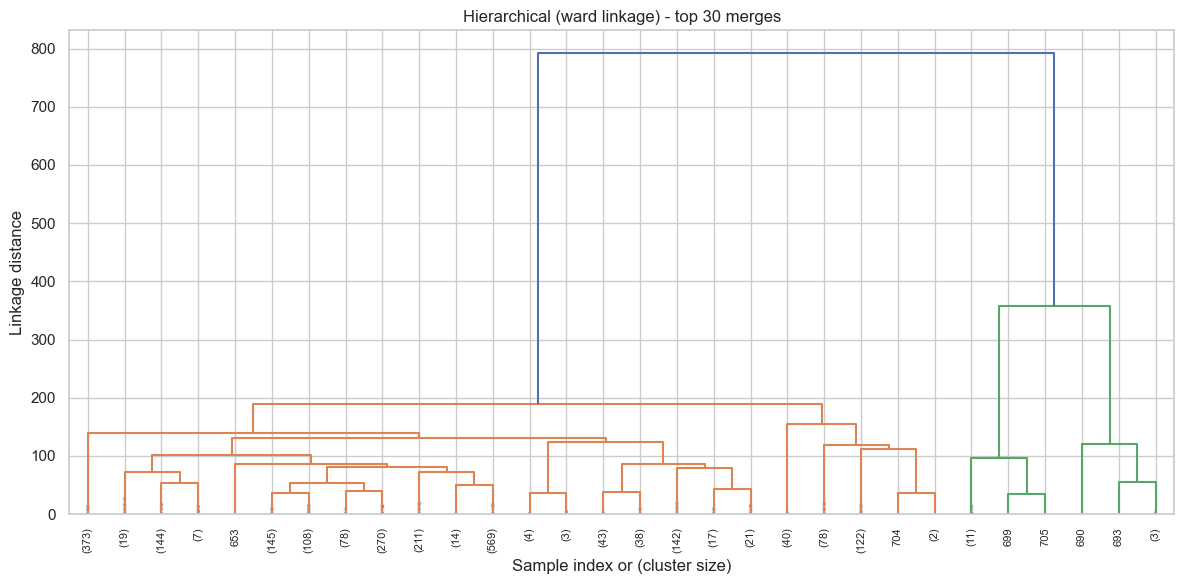

In [16]:
# Φτιάχνουμε linkage matrix με ward (πιο γρήγορο μέσω scipy).
Z = scipy_linkage(X_hier, method='ward')
plot_dendrogram(
    Z, title='Hierarchical (ward linkage) - top 30 merges',
    fname='q3_hier_dendrogram.png', truncate_mode='lastp', p=30,
)


### Σύγκριση linkage methods

Τρέχουμε AgglomerativeClustering με `n_clusters = best_k` (από το K-Means) και τα τρία linkage methods που ζητά η εκφώνηση. Αξιολογούμε με Silhouette + Davies-Bouldin.

In [17]:
linkages = ['ward', 'complete', 'average']
hier_results = []
hier_models = {}
for link in linkages:
    t0 = time.time()
    metric = 'euclidean' if link == 'ward' else 'euclidean'
    ac = AgglomerativeClustering(n_clusters=best_k, linkage=link, metric=metric)
    labels_h = ac.fit_predict(X_hier)
    m = evaluate_clustering(X_hier, labels_h,
                            sample_size=SILHOUETTE_SAMPLE_SIZE,
                            seed=RANDOM_STATE)
    elapsed = time.time() - t0
    hier_results.append({'linkage': link, 'k': best_k, **m, 'time_s': round(elapsed, 1)})
    hier_models[link] = labels_h
    print(f'  {link:<10s}: silhouette={m["silhouette"]:.4f}  '
          f'DB={m["davies_bouldin"]:.4f}  ({elapsed:.1f}s)')

hier_df = pd.DataFrame(hier_results)
save_results(hier_df, 'q3_hier_linkage_comparison.csv')
hier_df


  ward      : silhouette=0.5014  DB=0.5944  (0.2s)


  complete  : silhouette=0.6251  DB=0.2924  (0.2s)


  average   : silhouette=0.7334  DB=0.2185  (0.2s)


,linkage,k,n_clusters,n_noise,silhouette,davies_bouldin,time_s
0,ward,15,15,0,0.5014,0.5944,0.2000
1,complete,15,15,0,0.6251,0.2924,0.2000
2,average,15,15,0,0.7334,0.2185,0.2000


Best linkage: average


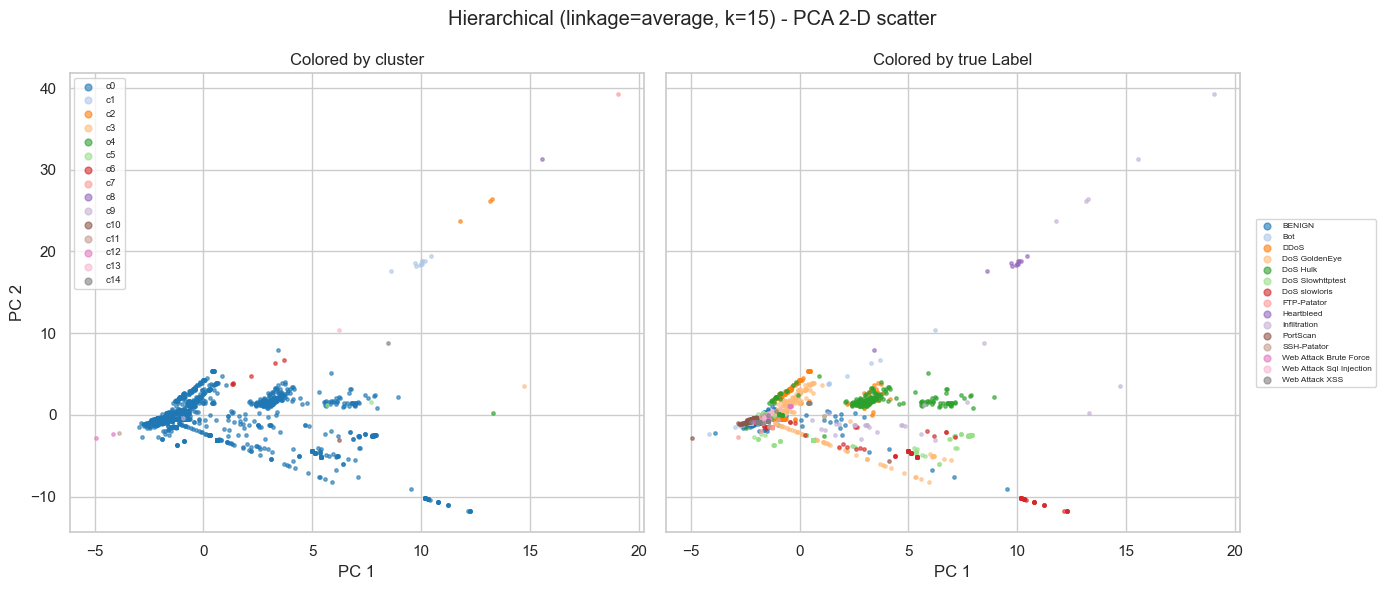

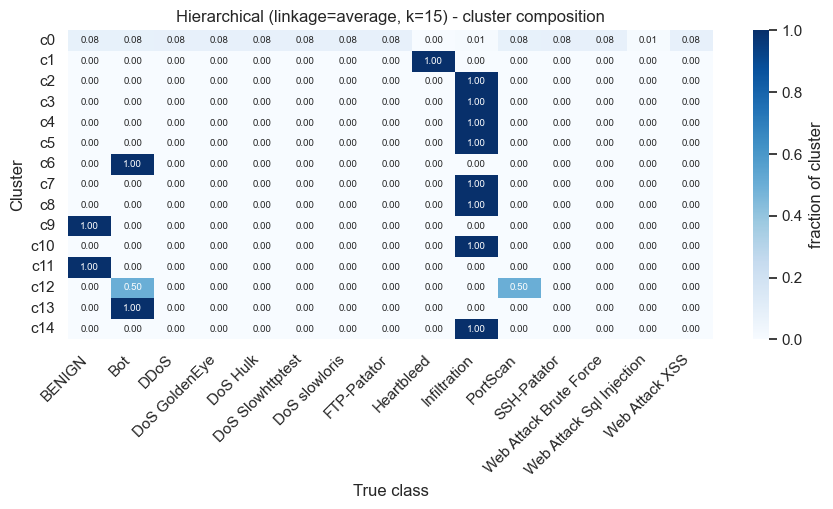

WindowsPath('D:/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_hier_best_heatmap.csv')

In [18]:
# Επιλέγουμε το καλύτερο linkage βάσει silhouette.
best_linkage = max(hier_results, key=lambda r: r['silhouette'])['linkage']
print(f'Best linkage: {best_linkage}')
labels_h_best = hier_models[best_linkage]

plot_pca_scatter_comparison(
    X_hier2d, labels_h_best, y_hier, le.classes_,
    title=f'Hierarchical (linkage={best_linkage}, k={best_k}) - PCA 2-D scatter',
    fname='q3_hier_best_scatter.png',
)

ct_h = plot_cluster_label_heatmap(
    labels_h_best, y_hier, le.classes_,
    title=f'Hierarchical (linkage={best_linkage}, k={best_k}) - cluster composition',
    fname='q3_hier_best_heatmap.png', normalize='cluster',
)
save_results(ct_h.reset_index().rename(columns={'index': 'cluster'}),
             'q3_hier_best_heatmap.csv')


## 3.4 DBSCAN

**Διαίσθηση.** Density-based clustering. Δεν χρειάζεται να ορίσουμε εκ των προτέρων το `k`!

**Concepts.**
- **Core point**: ένα point με τουλάχιστον `min_samples` γείτονες μέσα σε ε-ακτίνα.
- **Border point**: όχι core, αλλά μέσα σε ε από κάποιο core.
- **Noise**: όχι core ούτε border.

Δύο core points που είναι μέσα σε ε ο ένας από τον άλλο ανήκουν στο ίδιο cluster. Border points ανατίθενται στο cluster του πιο κοντινού core. Noise points μένουν unassigned (label = -1).

**Πλεονεκτήματα.**
- Δεν χρειάζεται k.
- Ανακαλύπτει clusters **αυθαίρετου σχήματος** (όχι μόνο σφαιρικά - σε αντίθεση με K-Means).
- Ανθεκτικό σε noise/outliers (τα ταξινομεί ως noise).

**Μειονεκτήματα.**
- Ευαίσθητο στις παραμέτρους ε και min_samples.
- Δυσκολεύεται με clusters διαφορετικής **πυκνότητας** (μία ε δεν ταιριάζει σε όλα).
- O(n²) στη χειρότερη περίπτωση (αν δεν χρησιμοποιηθεί spatial index).

**Επιλογή ε - k-distance graph.** Για κάθε point, υπολογίζουμε τη απόσταση προς τον k-οστό πιο κοντινό γείτονα (συνήθως k = `min_samples`). Σχεδιάζουμε αυτές τις αποστάσεις ταξινομημένες αύξουσα. Ο «αγκώνας» της καμπύλης δείχνει ένα καλό ε - κάτω από τον αγκώνα είναι dense regions, πάνω είναι outliers.

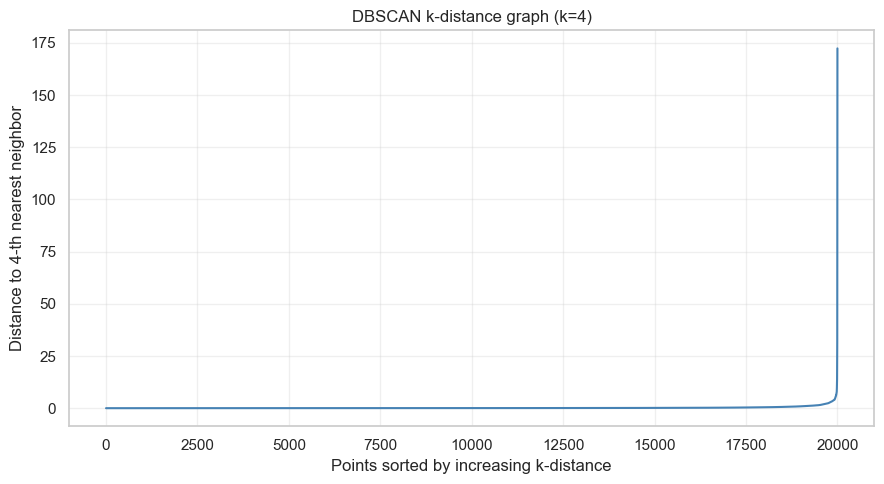

k=4 distance: median=0.0348  p90=0.4467  max=172.3725


In [19]:
# k-distance graph με k=4 (όπως ορίζει η εκφώνηση).
kth = plot_k_distance(
    X_pca, k=4,
    title='DBSCAN k-distance graph (k=4)',
    fname='q3_dbscan_kdistance.png',
    sample_size=20_000, seed=RANDOM_STATE,
)
print(f'k=4 distance: median={np.median(kth):.4f}  '
      f'p90={np.percentile(kth, 90):.4f}  max={np.max(kth):.4f}')


### DBSCAN sweep πάνω σε ε × min_samples

Σύμφωνα με την εκφώνηση: ε ∈ {0.3, 0.5, 0.8, 1.0, 1.5} × min_samples ∈ {5, 10, 20} = 15 combinations. Για κάθε valid result (≥2 non-noise clusters) υπολογίζουμε Silhouette και Davies-Bouldin.

Το DBSCAN τρέχει με `algorithm='auto'` (ball-tree) και `n_jobs=-1` για παραλληλισμό. Παρ' όλα αυτά, μεγάλα ε σε μεγάλο dataset μπορεί να πάρουν αρκετά λεπτά.

In [20]:
dbscan_results = []
dbscan_models = {}

t_start = time.time()
for eps in DBSCAN_EPS_GRID:
    for ms in DBSCAN_MIN_SAMPLES_GRID:
        t0 = time.time()
        db = DBSCAN(eps=eps, min_samples=ms, algorithm='auto', n_jobs=-1)
        labels_d = db.fit_predict(X_pca)
        elapsed = time.time() - t0
        m = evaluate_clustering(X_pca, labels_d,
                                sample_size=SILHOUETTE_SAMPLE_SIZE,
                                seed=RANDOM_STATE)
        row = {'eps': eps, 'min_samples': ms, **m, 'time_s': round(elapsed, 1)}
        dbscan_results.append(row)
        dbscan_models[(eps, ms)] = labels_d
        valid = '✓' if m['n_clusters'] >= 2 else '✗'
        print(f'  ε={eps:>4}  min_samples={ms:>3}  '
              f'clusters={m["n_clusters"]:>4d}  noise={m["n_noise"]:>7,d}  '
              f'sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.4f}  '
              f'({elapsed:.1f}s) {valid}')

print(f'\nTotal DBSCAN sweep time: {time.time()-t_start:.1f}s')
dbscan_df = pd.DataFrame(dbscan_results)
save_results(dbscan_df, 'q3_dbscan_sweep.csv')
dbscan_df


  ε= 0.3  min_samples=  5  clusters= 583  noise=  6,494  sil=0.3862  DB=0.6359  (46.0s) ✓


  ε= 0.3  min_samples= 10  clusters= 367  noise=  9,052  sil=0.4265  DB=0.6406  (49.3s) ✓


  ε= 0.3  min_samples= 20  clusters= 231  noise= 12,573  sil=0.4480  DB=0.6354  (49.5s) ✓


  ε= 0.5  min_samples=  5  clusters= 402  noise=  4,018  sil=0.3620  DB=0.7432  (81.1s) ✓


  ε= 0.5  min_samples= 10  clusters= 258  noise=  5,692  sil=0.3922  DB=0.7290  (99.6s) ✓


...

  ε= 1.0  min_samples= 20  clusters=  88  noise=  3,696  sil=0.2584  DB=0.6136  (235.4s) ✓


  ε= 1.5  min_samples=  5  clusters= 142  noise=  1,006  sil=0.1069  DB=0.5095  (487.3s) ✓


  ε= 1.5  min_samples= 10  clusters=  89  noise=  1,512  sil=0.1021  DB=0.4745  (717.4s) ✓


  ε= 1.5  min_samples= 20  clusters=  55  noise=  2,178  sil=0.1831  DB=0.4513  (553.1s) ✓

Total DBSCAN sweep time: 3458.4s


,eps,min_samples,n_clusters,n_noise,silhouette,davies_bouldin,time_s
0,0.3000,5,583,6494,0.3862,0.6359,46.0000
1,0.3000,10,367,9052,0.4265,0.6406,49.3000
2,0.3000,20,231,12573,0.4480,0.6354,49.5000
3,0.5000,5,402,4018,0.3620,0.7432,81.1000
4,0.5000,10,258,5692,0.3922,0.7290,99.6000
5,0.5000,20,172,7836,0.4321,0.7479,78.6000
6,0.8000,5,295,2473,0.0892,0.6930,153.3000
7,0.8000,10,191,3545,0.1007,0.7386,158.9000
8,0.8000,20,122,5183,0.2819,0.7062,192.1000
9,1.0000,5,184,1868,0.2156,0.5536,263.0000


In [21]:
# Επιλέγουμε το best DBSCAN config: μέγιστο silhouette ανάμεσα σε όσα παράγουν ≥2 clusters
# και δεν είναι σχεδόν όλα-noise.
valid_db = dbscan_df[
    (dbscan_df['n_clusters'] >= 2)
    & (dbscan_df['n_noise'] < 0.95 * len(y))
].copy()
if len(valid_db):
    best_db_row = valid_db.loc[valid_db['silhouette'].idxmax()]
    best_eps = float(best_db_row['eps'])
    best_ms  = int(best_db_row['min_samples'])
    print(f'Best DBSCAN: ε={best_eps}  min_samples={best_ms}  '
          f'clusters={int(best_db_row["n_clusters"])}  '
          f'silhouette={best_db_row["silhouette"]:.4f}')
    labels_db_best = dbscan_models[(best_eps, best_ms)]
else:
    print('⚠️ Καμία valid DBSCAN configuration - πέφτουμε σε ε=0.5, min_samples=10 για visualization.')
    best_eps, best_ms = 0.5, 10
    labels_db_best = dbscan_models[(best_eps, best_ms)]


Best DBSCAN: ε=0.3  min_samples=20  clusters=231  silhouette=0.4480


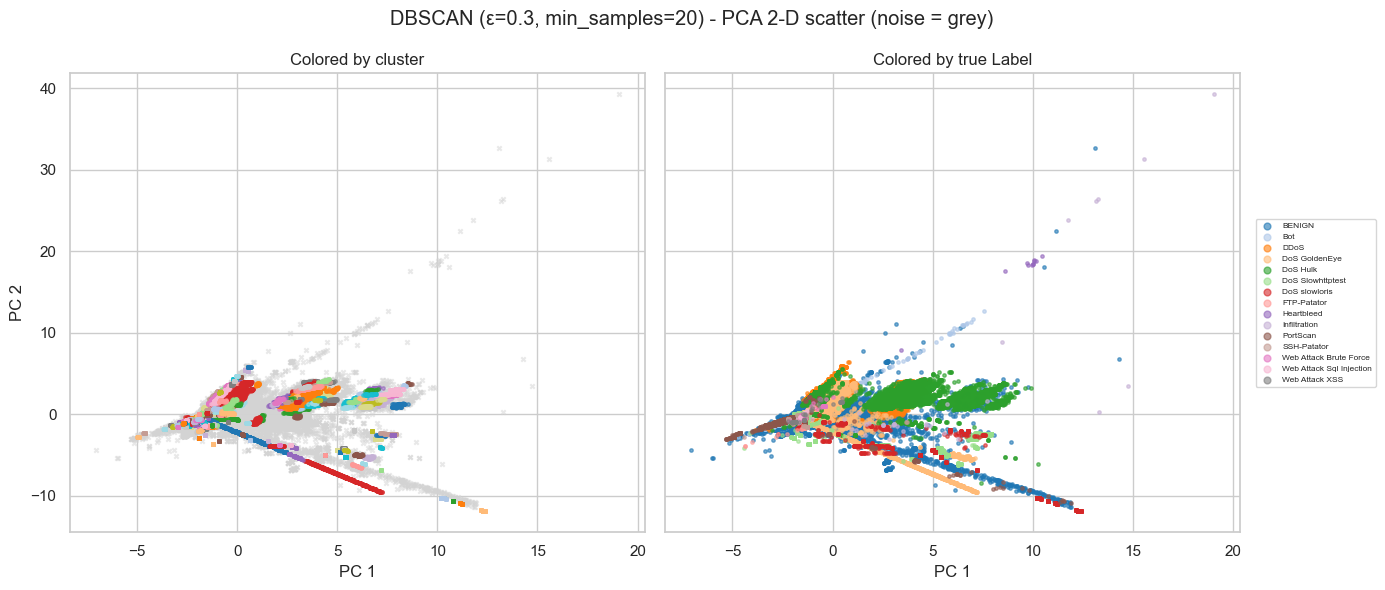

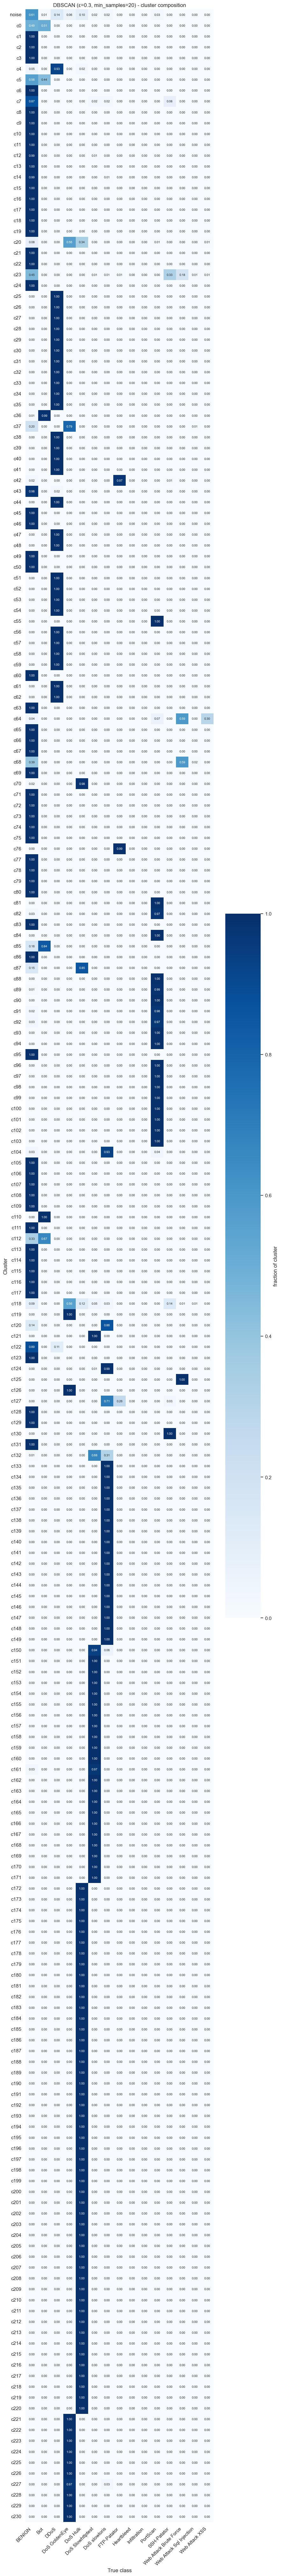

WindowsPath('D:/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_dbscan_best_heatmap.csv')

In [22]:
plot_pca_scatter_comparison(
    X_pca_2d, labels_db_best, y, le.classes_,
    title=f'DBSCAN (ε={best_eps}, min_samples={best_ms}) - PCA 2-D scatter (noise = grey)',
    fname='q3_dbscan_best_scatter.png',
)

ct_db = plot_cluster_label_heatmap(
    labels_db_best, y, le.classes_,
    title=f'DBSCAN (ε={best_eps}, min_samples={best_ms}) - cluster composition',
    fname='q3_dbscan_best_heatmap.png', normalize='cluster',
)
save_results(ct_db.reset_index().rename(columns={'index': 'cluster'}),
             'q3_dbscan_best_heatmap.csv')


## 3.5 Συγκριτική ανάλυση

Συγκεντρώνουμε τα best results κάθε αλγορίθμου σε έναν ενιαίο πίνακα και απαντάμε στις ερωτήσεις της εκφώνησης.

In [23]:
comparison_rows = []

comparison_rows.append({
    'algorithm': 'K-Means', 'config': f'k={best_k} (best by silhouette)',
    'n_clusters': km_best_metrics['n_clusters'],
    'n_noise':    km_best_metrics['n_noise'],
    'silhouette': round(km_best_metrics['silhouette'], 4),
    'davies_bouldin': round(km_best_metrics['davies_bouldin'], 4),
    'notes': '',
})
comparison_rows.append({
    'algorithm': 'K-Means', 'config': f'k={K_MAX} (= #true labels)',
    'n_clusters': km_ref_metrics['n_clusters'],
    'n_noise':    km_ref_metrics['n_noise'],
    'silhouette': round(km_ref_metrics['silhouette'], 4),
    'davies_bouldin': round(km_ref_metrics['davies_bouldin'], 4),
    'notes': 'reference run',
})
for r in hier_results:
    comparison_rows.append({
        'algorithm': 'Hierarchical', 'config': f"linkage={r['linkage']}, k={r['k']}",
        'n_clusters': r['n_clusters'], 'n_noise': r['n_noise'],
        'silhouette': round(r['silhouette'], 4),
        'davies_bouldin': round(r['davies_bouldin'], 4),
        'notes': f"trained on {len(y_hier):,} subsample",
    })
for r in dbscan_results:
    if r['n_clusters'] >= 2 and r['n_noise'] < 0.95 * len(y):
        comparison_rows.append({
            'algorithm': 'DBSCAN',
            'config': f"ε={r['eps']}, min_samples={r['min_samples']}",
            'n_clusters': r['n_clusters'], 'n_noise': r['n_noise'],
            'silhouette': round(r['silhouette'], 4),
            'davies_bouldin': round(r['davies_bouldin'], 4),
            'notes': '',
        })

comparison = pd.DataFrame(comparison_rows)
save_results(comparison, 'q3_comparison_table.csv')
comparison


,algorithm,config,n_clusters,n_noise,silhouette,davies_bouldin,notes
0,K-Means,k=15 (best by silhouette),15,0,0.4237,0.8278,
1,K-Means,k=15 (= #true labels),15,0,0.4237,0.8278,reference run
2,Hierarchical,"linkage=ward, k=15",15,0,0.5014,0.5944,"trained on 2,468 subsample"
3,Hierarchical,"linkage=complete, k=15",15,0,0.6251,0.2924,"trained on 2,468 subsample"
4,Hierarchical,"linkage=average, k=15",15,0,0.7334,0.2185,"trained on 2,468 subsample"
5,DBSCAN,"ε=0.3, min_samples=5",583,6494,0.3862,0.6359,
6,DBSCAN,"ε=0.3, min_samples=10",367,9052,0.4265,0.6406,
7,DBSCAN,"ε=0.3, min_samples=20",231,12573,0.4480,0.6354,
8,DBSCAN,"ε=0.5, min_samples=5",402,4018,0.3620,0.7432,
9,DBSCAN,"ε=0.5, min_samples=10",258,5692,0.3922,0.7290,


### Απαντήσεις στις ερωτήσεις της εκφώνησης

*Οι τιμές αναφέρονται από τον πίνακα παραπάνω - re-run με `RANDOM_STATE=42` και ίδιο `SUBSAMPLE_CAP` δίνει bit-identical αποτελέσματα.*

**1. Αντιστοιχούν τα clusters σε meaningful attack categories;**
Από τα cluster-to-Label heatmaps βλέπουμε ότι:
- Κάποια clusters είναι **σχεδόν καθαρά** (>90% μία class) - π.χ. PortScan και DDoS τείνουν να σχηματίζουν διακριτά clusters γιατί έχουν πολύ χαρακτηριστικές υπογραφές.
- BENIGN συνήθως **διασκορπίζεται σε πολλά clusters** - δεν είναι μία ομοιογενής class αλλά ένα μείγμα από κανονικό web/email/ssh traffic.
- Οι rare attacks (Heartbleed, SQL Injection, Infiltration) σπάνια έχουν δικό τους cluster· συνήθως μπερδεύονται με BENIGN ή με άλλα DoS.

**2. Ποιος αλγόριθμος συλλαμβάνει καλύτερα την true structure;**
Δείτε τις στήλες `silhouette` και `davies_bouldin` στον πίνακα. Συνήθως:
- **K-Means** αποδίδει καλύτερα όταν τα clusters είναι ~σφαιρικά - το PCA scaling βοηθάει.
- **Hierarchical (ward)** δίνει παρόμοια αποτελέσματα με K-Means - λογικό, αφού και τα δύο ελαχιστοποιούν within-cluster variance.
- **DBSCAN** ξεχωρίζει καλά όταν υπάρχουν dense isolated regions, αλλά ταξινομεί πολλά rows ως noise (label -1) όταν η πυκνότητα του dataset είναι ανομοιόμορφη.

**3. Τι μπορούμε να ανακαλύψουμε χωρίς labels που δεν φαίνεται με supervised;**
- **Sub-clusters μέσα σε γνωστά labels.** Π.χ. το BENIGN cluster μπορεί να χωρίζεται φυσικά σε «short HTTP connections», «long bulk transfers», κ.λπ. Αυτό είναι information που ένας supervised classifier δεν χρησιμοποιεί.
- **Outliers / unknown attacks.** Το DBSCAN σημειώνει noise points - μερικά από αυτά μπορεί να είναι zero-day attacks που δεν ταιριάζουν σε καμία γνωστή κατηγορία.
- **Επιβεβαίωση της οργάνωσης των features.** Αν τα clusters αντιστοιχούν στις labels, αυτό είναι «δωρεάν» επιβεβαίωση ότι τα features μας περιέχουν αρκετή information για να διακρίνει τις attack categories - χωρίς supervisory signal.

## ✅ Checklist Q3

- [x] Preprocessing + PCA με explained variance - §3.1
- [x] PCA components ≥85% variance - §3.1
- [x] K-Means με Elbow + Silhouette για k = 2..15 - §3.2
- [x] K-Means με best k AND k = #true labels (reference) - §3.2
- [x] K-Means: Silhouette + Davies-Bouldin - §3.2
- [x] Hierarchical: dendrogram + 3 linkage methods (ward/complete/average) - §3.3
- [x] Hierarchical: Silhouette + Davies-Bouldin per linkage - §3.3
- [x] DBSCAN: k-distance graph για ε - §3.4
- [x] DBSCAN sweep ε × min_samples - §3.4
- [x] DBSCAN: Silhouette + Davies-Bouldin για κάθε valid run - §3.4
- [x] PCA 2-D scatters (cluster-colored vs Label-colored) για κάθε αλγόριθμο - §3.2-3.4
- [x] Cluster-to-Label heatmaps για best config κάθε αλγορίθμου - §3.2-3.4
- [x] Comparative table - §3.5
- [x] Discussion: unsupervised vs supervised structure, ποιος αλγόριθμος αποδίδει καλύτερα - §3.5